# **Análisis exploratorio de datos**

### *Default clients*

0. Importación de librerias 

In [ ]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Carga de datos 

In [2]:
ruta_archivo = "../data/raw/Default_Clientes.csv"
df = pd.read_csv(ruta_archivo, sep=";")

print("\n--- Estructura inicial del Dataset ---")
print(df.info())
print("\n", df.describe())


--- Estructura inicial del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3  

2. Limpieza e imputación 

In [3]:
# 1. Separar la variable objetivo de las predictoras para no imputar el target
target_col = 'Default'

cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas.remove(target_col) # No tocar el target
# Remover ID que no aporta información predictiva
if 'ID' in cols_numericas:
    cols_numericas.remove('ID')
    
cols_texto = df.select_dtypes(include=['object']).columns.tolist()

# 2. Imputación: mediana para numéricas, moda para categóricas (texto)
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

if cols_texto:
    for col in cols_texto:
        df[col] = df[col].fillna(df[col].mode()[0])

# 3. Convertir variables que conceptualmente son categóricas al tipo 'category'
# Ojo: Mantenemos 'Default' como int (0 y 1) para SMOTE y modelos
cols_categoricas = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", 
                    "PAY_4", "PAY_5", "PAY_6"]

for col in cols_categoricas:
    if col in df.columns:
        # Primero llenamos nulos en estas columnas categóricas numéricas con la moda
        df[col] = df[col].fillna(df[col].mode()[0])
        df[col] = df[col].astype('category')
    else:
        print(f"Advertencia: columna '{col}' no encontrada")

print("\nLimpieza e imputación completada.")
print(f"Columnas categóricas: {df.select_dtypes(include=['category']).columns.tolist()}")


Limpieza e imputación completada.
Columnas categóricas: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


2. 1 Que se hizo en esta limpieza 
Este bloque de código se encarga de preparar la base de datos para el modelado, asegurando que no haya valores nulos (vacíos) y que cada variable tenga el tipo de dato correcto. El proceso se dividió en tres pasos fundamentales:

1. Aislamiento de la Variable Objetivo y Exclusión de Identificadores
¿Qué se hizo? Se identificaron automáticamente todas las columnas numéricas, pero se excluyó explícitamente la variable objetivo (Default) y la columna de identificación (ID).

¿Por qué? * La columna ID se elimina porque es un simple número de registro que no aporta ningún poder predictivo al modelo; incluirla generaría "ruido".

La variable Default (el Target) se aísla para protegerla. Imputar o modificar la variable que queremos predecir es un error grave en Data Science (conocido como Data Leakage o fuga de datos), ya que inventaríamos información sobre quién pagó y quién no.

2. Imputación Estratégica de Valores Nulos
¿Qué se hizo? Se rellenaron los datos faltantes en las variables numéricas utilizando la mediana, y en las variables de texto utilizando la moda (el valor más frecuente).

¿Por qué? Se decidió usar la mediana en lugar del promedio (media) debido a los hallazgos del Análisis Exploratorio (EDA). Al descubrir que variables como el límite de crédito (LIMIT_BAL) o los montos de pago tienen valores atípicos extremos (clientes con deudas gigantescas), el promedio se habría visto fuertemente distorsionado. La mediana es una medida robusta que no se deja afectar por estos outliers, garantizando una imputación mucho más realista y segura.

3. Conversión y Tratamiento de Variables Categóricas
¿Qué se hizo? Se agrupó un conjunto específico de variables (SEX, EDUCATION, MARRIAGE y el historial de pagos PAY_0 a PAY_6). Se les aplicó una imputación por moda (en caso de tener nulos) y se transformaron forzosamente al tipo de dato category. Sin embargo, la variable objetivo Default se mantuvo como un número entero (0 y 1).

¿Por qué?

Corrección conceptual: Aunque en la base de datos el sexo o la educación estén representados con números (ej. 1, 2, 3), conceptualmente no son cantidades medibles, sino "etiquetas". Convertirlas a category optimiza el uso de memoria de Pandas y le indica a los futuros algoritmos que no pueden hacer operaciones matemáticas con ellas (por ejemplo, no tiene sentido promediar el estado civil).

Compatibilidad técnica: Mantener Default como entero (int) es una decisión técnica estricta. Algoritmos avanzados que se usarán en las siguientes etapas, como el balanceo de clases con SMOTE, exigen que la variable objetivo sea numérica binaria para funcionar correctamente.

3. ESTADÍSTICAS DESCRIPTIVAS POST-LIMPIEZA

In [4]:
print("\n--- Resumen de Datos Limpios ---")
print(df.describe(include='all'))



--- Resumen de Datos Limpios ---
                  ID       LIMIT_BAL      SEX  EDUCATION  MARRIAGE  \
count   30000.000000    30000.000000  30000.0    30000.0   30000.0   
unique           NaN             NaN      2.0        7.0       4.0   
top              NaN             NaN      2.0        2.0       2.0   
freq             NaN             NaN  18112.0    14030.0   15964.0   
mean    15000.500000   167484.322667      NaN        NaN       NaN   
std      8660.398374   129747.661567      NaN        NaN       NaN   
min         1.000000    10000.000000      NaN        NaN       NaN   
25%      7500.750000    50000.000000      NaN        NaN       NaN   
50%     15000.500000   140000.000000      NaN        NaN       NaN   
75%     22500.250000   240000.000000      NaN        NaN       NaN   
max     30000.000000  1000000.000000      NaN        NaN       NaN   

                 AGE    PAY_0    PAY_2    PAY_3    PAY_4  ...      BILL_AMT4  \
count   30000.000000  30000.0  30000.0  30000

3. 1    Analisis estadisticas descriptivas pos-limpieza 

1 Datos limpios: 30,000 registros completos. La imputación eliminó todos los nulos.

2 Perfil (AGE, LIMIT_BAL): Cartera joven (75% ≤ 41 años). Cupos fuertemente sesgados: la mayoría son bajos/medios, pero unos pocos llegan al millón.

3 Comportamiento (BILL_AMT, PAY_AMT): Existen saldos a favor (facturas negativas) y outliers extremos (desviaciones estándar gigantes por clientes con deudas/pagos atípicos)

4. VISUALIZACIÓN DE DATOS

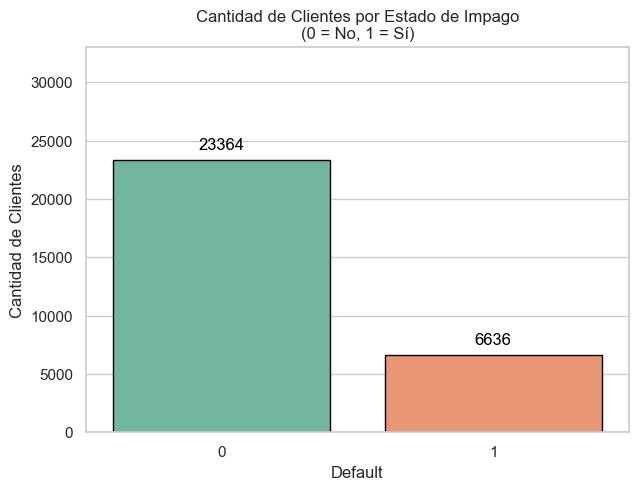

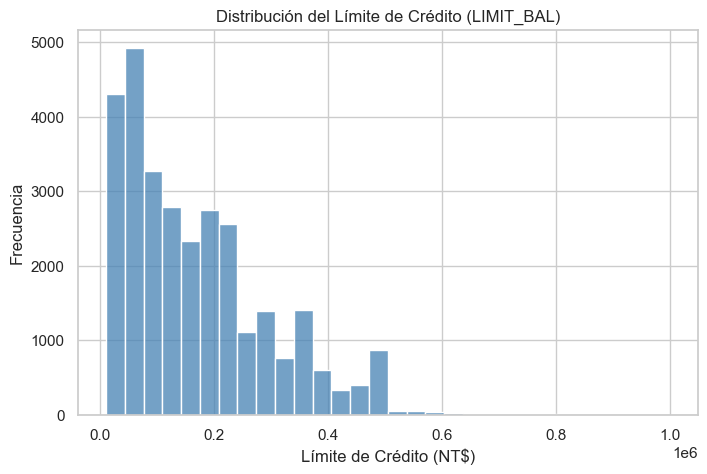

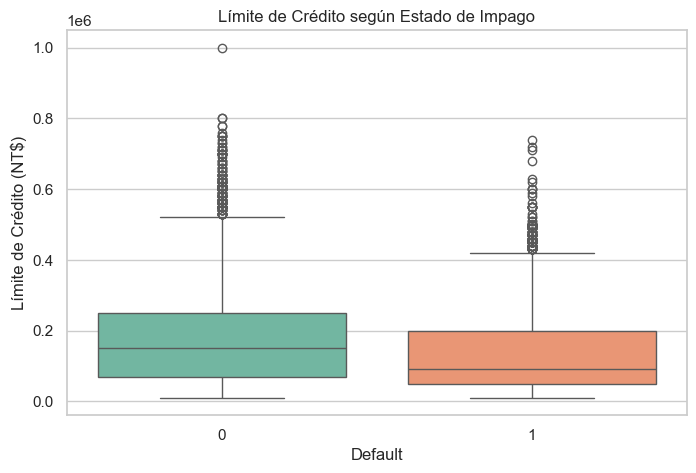

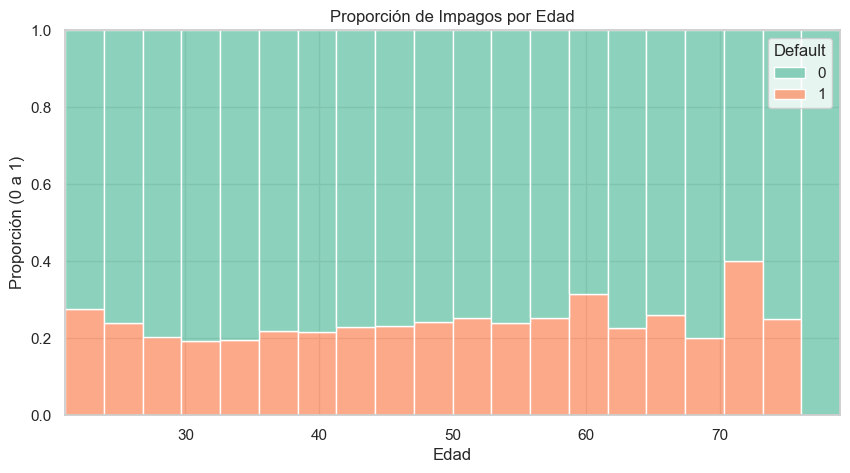

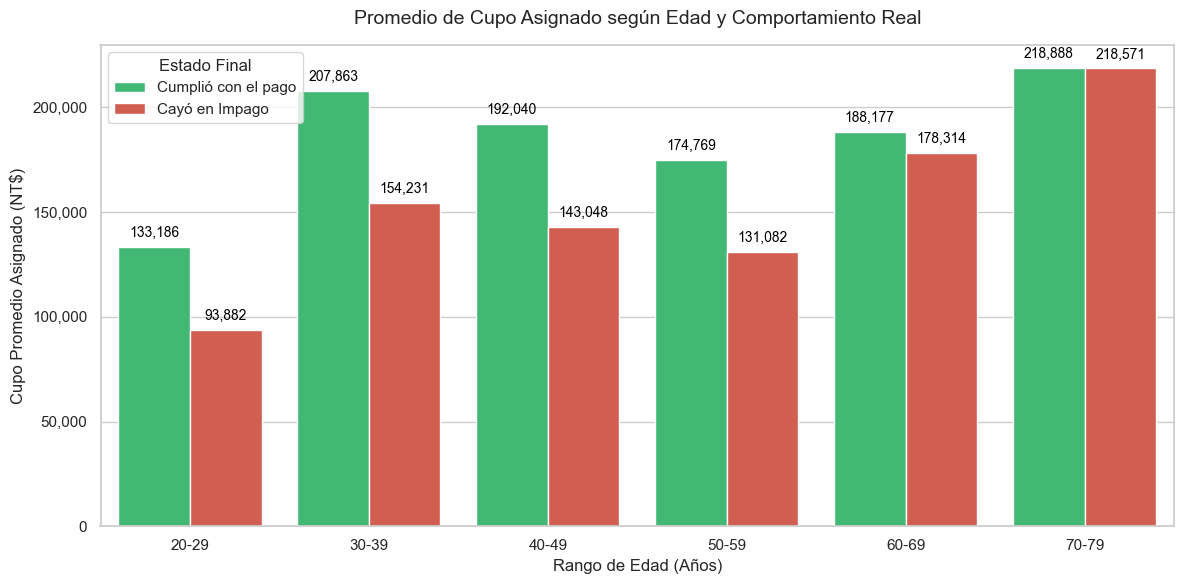


--- TABLA MAESTRA DE RIESGO CREDITICIO POR EDAD ---


Default,Cumplieron (0),Impago (1),Subtotal Fila,% Riesgo (Fila),% Peso sobre Total
Rango_Edad,,,,,
20-29,7421,2197,9618,22.84%,32.06%
30-39,8962,2276,11238,20.25%,37.46%
40-49,4979,1485,6464,22.97%,21.55%
50-59,1759,582,2341,24.86%,7.8%
60-69,225,89,314,28.34%,1.05%
70-79,18,7,25,28.0%,0.08%
GRAN TOTAL,23364,6636,30000,22.12%,100.0%


In [ ]:
# ==============================================================================
# DETECCIÓN AUTOMÁTICA DE LA VARIABLE OBJETIVO (Anti-errores de mayúsculas)
# ==============================================================================
target = 'DEFAULT' if 'DEFAULT' in df.columns else 'Default'

# Configuración de estilo general
sns.set_theme(style="whitegrid")

# ==============================================================================
# a) Análisis de Impagos: Conteo exacto
# ==============================================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=target, hue=target, palette='Set2', edgecolor='black', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.title(f'Cantidad de Clientes por Estado de Impago\n(0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.ylim(0, len(df) * 1.1) 
plt.show()

# ==============================================================================
# b) Histograma del límite de crédito (LIMIT_BAL) - Limpio
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(df['LIMIT_BAL'], bins=30, color='steelblue', kde=False)
plt.title('Distribución del Límite de Crédito (LIMIT_BAL)')
plt.xlabel('Límite de Crédito (NT$)')
plt.ylabel('Frecuencia')
plt.show()

# ==============================================================================
# c) Boxplot de Límite de crédito vs Impago
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target, y='LIMIT_BAL', hue=target, palette='Set2', legend=False)
plt.title('Límite de Crédito según Estado de Impago')
plt.ylabel('Límite de Crédito (NT$)')
plt.show()

# ==============================================================================
# d) Proporción de Impagos por Edad
# ==============================================================================
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='AGE', hue=target, multiple='fill', bins=20, palette='Set2')
plt.title('Proporción de Impagos por Edad')
plt.xlabel('Edad')
plt.ylabel('Proporción (0 a 1)')
plt.show()

# ==============================================================================
# e) Promedio de Límite de Crédito por Rango de Edad (VERSIÓN EJECUTIVA)
# ==============================================================================
# 1. Aseguramos que existan los rangos y la variable objetivo correcta
target = 'DEFAULT' if 'DEFAULT' in df.columns else 'Default'
bins = [20, 30, 40, 50, 60, 70, 80]
etiquetas = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['Rango_Edad'] = pd.cut(df['AGE'], bins=bins, labels=etiquetas, right=False)

plt.figure(figsize=(12, 6)) # Lo hacemos un poco más ancho para que respiren los números

# 2. Creamos el gráfico con colores intuitivos (Verde = Pago, Rojo = Riesgo)
colores_financieros = ['#2ecc71', '#e74c3c'] 
ax = sns.barplot(data=df, x='Rango_Edad', y='LIMIT_BAL', hue=target, 
                 palette=colores_financieros, errorbar=None)

# 3. Títulos y etiquetas directas
plt.title('Promedio de Cupo Asignado según Edad y Comportamiento Real', fontsize=14, pad=15)
plt.xlabel('Rango de Edad (Años)', fontsize=12)
plt.ylabel('Cupo Promedio Asignado (NT$)', fontsize=12)

# 4. Formatear el eje Y con separadores de miles (ej. 150,000)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))

# 5. Agregar la leyenda traducida a "humano"
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Cumplió con el pago', 'Cayó en Impago'], title='Estado Final', loc='upper left')

# 6. Magia: Poner los números exactos encima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Validar que la barra no esté vacía
        ax.annotate(f'{int(altura):,}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Limpieza
df = df.drop(columns=['Rango_Edad'], errors='ignore')




# ==============================================================================
# f) Tabla Maestra: Comportamiento de Pago con Totales y Peso Relativo
# ==============================================================================
import pandas as pd

# 1. Crear la variable de Rango_Edad (aseguramos que exista para este bloque)
bins = [20, 30, 40, 50, 60, 70, 80]
etiquetas = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
target = 'DEFAULT' if 'DEFAULT' in df.columns else 'Default'
df['Rango_Edad'] = pd.cut(df['AGE'], bins=bins, labels=etiquetas, right=False)

# 2. Creamos la tabla cruzada con MARGINS=TRUE para tener la fila y columna de totales
tabla_final = pd.crosstab(df['Rango_Edad'], df[target], margins=True, margins_name='GRAN TOTAL')

# 3. Renombrar columnas de las clases
tabla_final = tabla_final.rename(columns={0: 'Cumplieron (0)', 1: 'Impago (1)'})

# 4. CORRECCIÓN: Renombrar la columna de suma total (que Pandas llamó 'GRAN TOTAL')
tabla_final = tabla_final.rename(columns={'GRAN TOTAL': 'Subtotal Fila'})

# 5. Calcular % de Riesgo por Fila (Cuántos de este grupo fallaron)
tabla_final['% Riesgo (Fila)'] = (tabla_final['Impago (1)'] / tabla_final['Subtotal Fila'] * 100).round(2).astype(str) + '%'

# 6. Calcular % Representación sobre el Total (Peso de la fila frente a los 30,000)
# Usamos el valor exacto de la intersección del Gran Total para que sea dinámico
total_registros = tabla_final.loc['GRAN TOTAL', 'Subtotal Fila'] 
tabla_final['% Peso sobre Total'] = (tabla_final['Subtotal Fila'] / total_registros * 100).round(2).astype(str) + '%'

print("\n--- TABLA MAESTRA DE RIESGO CREDITICIO POR EDAD ---")
display(tabla_final)

# Limpieza: eliminamos la columna temporal
df = df.drop(columns=['Rango_Edad'], errors='ignore')

4. 1 Conclusiones por cada grafico 

a) Cantidad de Clientes por Estado de Default

Desbalance crítico: La cartera está dominada por clientes cumplidos (aprox. 78% vs 22% en default).

b) Distribución del Límite de Crédito (LIMIT_BAL)

Asimetría positiva: La distribución está muy sesgada a la derecha; la gran mayoría de los clientes recibe cupos bajos a moderados (hasta 200,000 NT$).

Clientes Élite: Existe una larga cola de valores atípicos reales correspondientes a un segmento muy exclusivo con cupos de hasta 1 millón NT$.

Política del banco: Refleja una estrategia de riesgo conservadora, otorgando montos controlables a la masa poblacional.

c) Límite de Crédito según Estado de Default (Boxplot)

Mayor cupo, menor riesgo: La caja de impagos (1) está más abajo, demostrando que los clientes con límites bajos son más propensos a fallar.

Fuerte poder predictivo: El límite de crédito otorgado por el banco actúa como un excelente filtro natural; los cupos altos (sobre 400,000 NT$) casi no presentan impagos.

d) Perfilamiento Preventivo: Los clientes en impago registraron, en promedio, cupos de crédito más bajos en todas las edades, sugiriendo que el monto asignado ya captura una señal de riesgo importante.

e) Variabilidad Etaria: Aunque el riesgo es persistente, se observan ligeras variaciones en la proporción de impagos según la década de vida, lo que amerita incluir la edad como variable predictiva.

f) Representatividad: El 70% de la cartera se concentra entre los 20 y 39 años, por lo que el comportamiento de este segmento será determinante para el rendimiento general del modelo futuro.

5. PRUEBAS DE NORMALIDAD Y CORRELACIÓN 


--- Evaluación de Normalidad (Asimetría y Curtosis) ---
Variable: LIMIT_BAL - ¿Aceptable? Sí (Asimetría: 0.99, Curtosis: 0.54)
Variable: AGE - ¿Aceptable? Sí (Asimetría: 0.73, Curtosis: 0.04)
Variable: BILL_AMT1 - ¿Aceptable? No (Asimetría: 2.66, Curtosis: 9.81)
Variable: BILL_AMT2 - ¿Aceptable? No (Asimetría: 2.71, Curtosis: 10.30)
Variable: BILL_AMT3 - ¿Aceptable? No (Asimetría: 3.09, Curtosis: 19.78)
Variable: BILL_AMT4 - ¿Aceptable? No (Asimetría: 2.82, Curtosis: 11.31)
Variable: BILL_AMT5 - ¿Aceptable? No (Asimetría: 2.88, Curtosis: 12.31)
Variable: BILL_AMT6 - ¿Aceptable? No (Asimetría: 2.85, Curtosis: 12.27)
Variable: PAY_AMT1 - ¿Aceptable? No (Asimetría: 14.67, Curtosis: 415.25)
Variable: PAY_AMT2 - ¿Aceptable? No (Asimetría: 30.45, Curtosis: 1641.63)
Variable: PAY_AMT3 - ¿Aceptable? No (Asimetría: 17.22, Curtosis: 564.31)
Variable: PAY_AMT4 - ¿Aceptable? No (Asimetría: 12.90, Curtosis: 277.33)
Variable: PAY_AMT5 - ¿Aceptable? No (Asimetría: 11.13, Curtosis: 180.06)
Variable: 

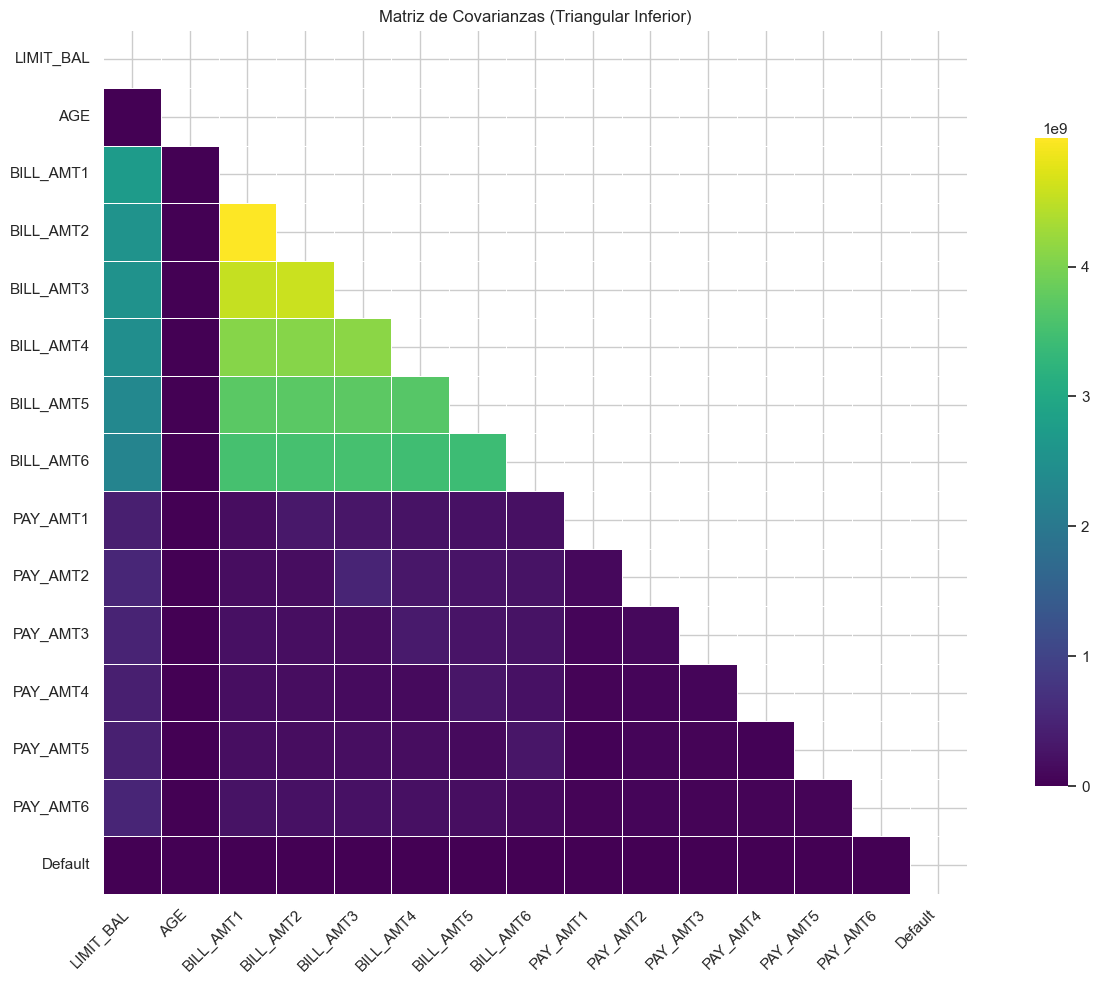


--- Generando Matriz de Correlación (Spearman) ---


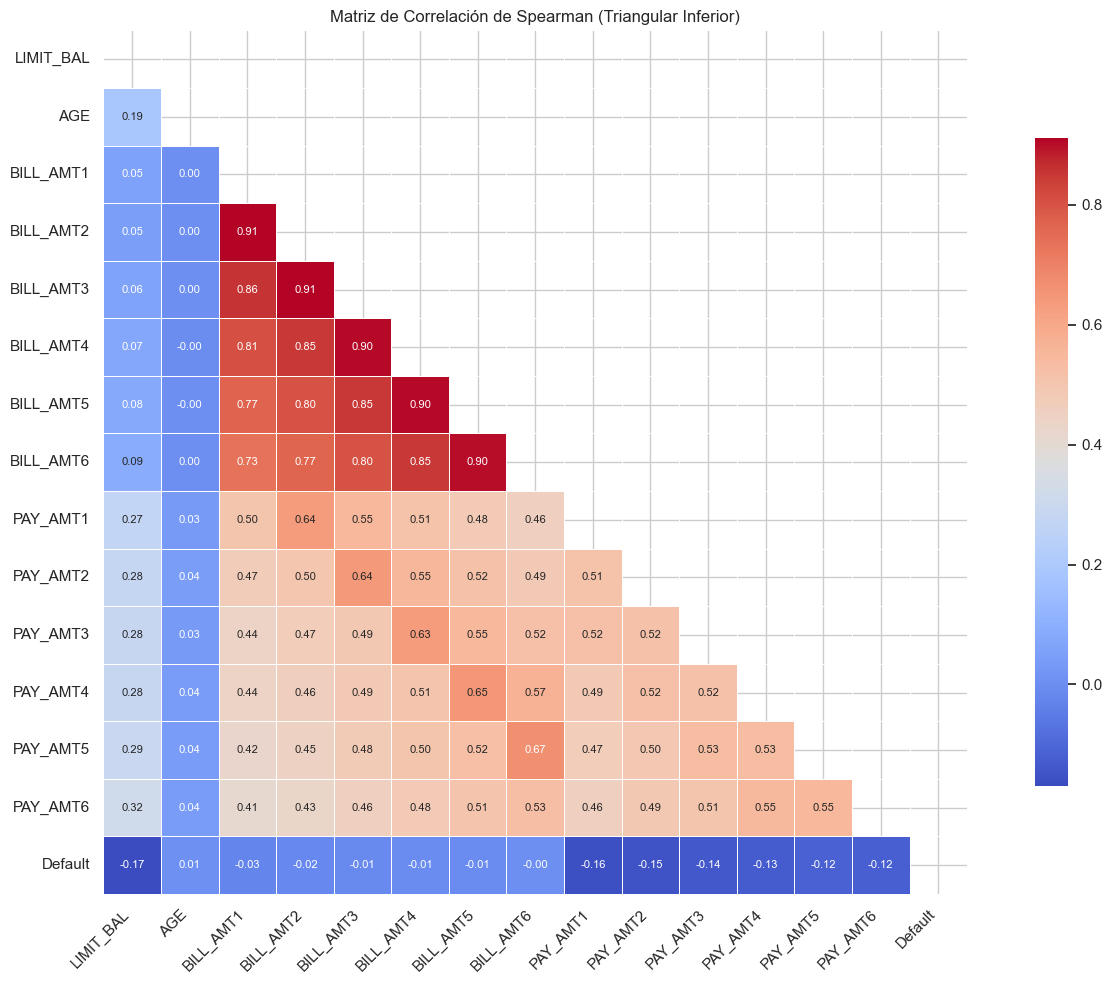


--- Generando Pairplot Estratégico ---


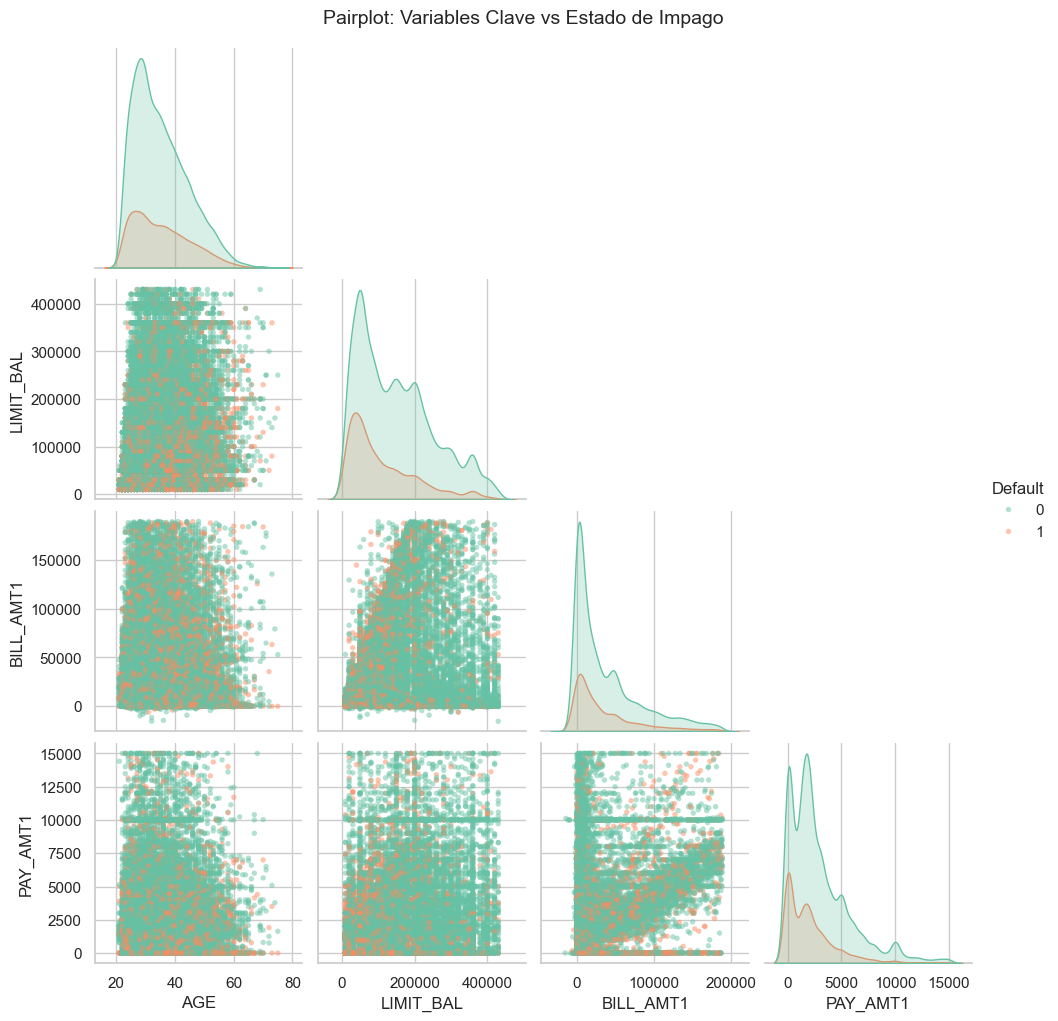

In [8]:
# ==============================================================================
# 0. PREPARACIÓN DE DATOS NUMÉRICOS
# ==============================================================================
df_numerico = df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')
target = 'DEFAULT' if 'DEFAULT' in df_numerico.columns else 'Default'

print("\n--- Evaluación de Normalidad (Asimetría y Curtosis) ---")
for col in df_numerico.columns:
    asimetria = df_numerico[col].skew()
    curtosis = df_numerico[col].kurtosis()
    es_aceptable = (abs(asimetria) < 2) and (abs(curtosis) < 2)
    print(f"Variable: {col} - ¿Aceptable? {'Sí' if es_aceptable else 'No'} (Asimetría: {asimetria:.2f}, Curtosis: {curtosis:.2f})")

# ==============================================================================
# 1. MATRIZ DE COVARIANZAS (Diferencias de escalas)
# ==============================================================================
print("\n--- Generando Matriz de Covarianzas ---")
matriz_cov = df_numerico.cov()

# Crear máscara para ocultar el triángulo superior (evitar redundancia)
mask_cov = np.triu(np.ones_like(matriz_cov, dtype=bool))

plt.figure(figsize=(14, 10))
# No ponemos anotaciones numéricas porque las covarianzas tienen escalas de miles de millones
sns.heatmap(matriz_cov, mask=mask_cov, annot=False, cmap='viridis', 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Matriz de Covarianzas (Triangular Inferior)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. MATRIZ DE CORRELACIÓN DE SPEARMAN
# ==============================================================================
print("\n--- Generando Matriz de Correlación (Spearman) ---")
matriz_cor = df_numerico.corr(method='spearman')

# Crear máscara para ocultar el triángulo superior
mask_cor = np.triu(np.ones_like(matriz_cor, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_cor, mask=mask_cor, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={"shrink": .75},
            annot_kws={"size": 8})
plt.title('Matriz de Correlación de Spearman (Triangular Inferior)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. PAIRPLOT MEJORADO (Filtro de percentiles para visualización)
# ==============================================================================
print("\n--- Generando Pairplot Estratégico ---")
# Seleccionamos 1 variable clave de cada categoría
columnas_estrategicas = ['AGE', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1', target]
cols_validas = [col for col in columnas_estrategicas if col in df.columns]

# Copia temporal y filtro del 5% de outliers para visibilidad
df_plot = df[cols_validas].copy()
for col in ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']:
    if col in df_plot.columns:
        df_plot = df_plot[df_plot[col] <= df_plot[col].quantile(0.95)]

# Gráfico
sns.pairplot(df_plot, hue=target, palette='Set2', corner=True, 
             plot_kws={'alpha': 0.5, 's': 15, 'linewidth': 0})
plt.suptitle('Pairplot: Variables Clave vs Estado de Impago', y=1.02, fontsize=14)
plt.show()

6. Conclusiones

1. Desbalance de clases: La gran mayoría de clientes cumple con sus pagos, por lo que cualquier modelo predictivo exigirá técnicas de balanceo.

2. Riesgo por cupo: A menor límite de crédito otorgado, mayor es la tasa de impago.

3. Distribución no normal: Las variables financieras presentan valores extremos, obligando a usar métodos no paramétricos como la correlación de Spearman.

4. Multicolinealidad: Los montos de facturación mensual son casi idénticos entre sí, requiriendo reducción de dimensionalidad para evitar redundancias.

5. Predictor principal: El estado del pago del último mes es el indicador más fuerte y definitivo para predecir el riesgo de default.

6. Covarianzas (Escalas): Diferencias extremas de magnitud (órdenes de $10^9$) hacen estrictamente necesario aplicar un método de escalado antes de modelar.

7. Spearman (Colinealidad): La alta correlación (aprox. 0.90) entre los montos de facturación mensual evidencia redundancia, justificando metodológicamente la aplicación de PCA para reducir dimensiones.

8. Pairplot (Separabilidad): En las nubes de puntos se observa una mezcla densa entre los clientes que pagaron (0) y los que cayeron en impago (1), sin que exista una división clara entre ambos grupos, esto sugiere que el fenómeno del default no puede explicarse mediante una sola variable o una regla simple.

7. Diccionario de datos

In [4]:
import pandas as pd
from IPython.display import display

# ==============================================================================
# DICCIONARIO DE DATOS: Default of Credit Card Clients
# ==============================================================================

# 1. Crear el diccionario de datos (Textos un poco más limpios)
datos = {
    'Variable': [
        "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", 
        "AGE", "PAY_0 a PAY_6", "BILL_AMT1 a BILL_AMT6", 
        "PAY_AMT1 a PAY_AMT6", "DEFAULT"
    ],
    'Tipo de Dato': [
        "Identificador", "Numérico Continuo", "Categórico Nominal", 
        "Categórico Ordinal", "Categórico Nominal", "Numérico Discreto", 
        "Categórico Ordinal", "Numérico Continuo", "Numérico Continuo", 
        "Categórico Nominal (Booleano)"
    ],
    'Descripción': [
        "ID único de registro para cada cliente.",
        "Límite de crédito otorgado (en NT$). Incluye crédito individual y suplementario familiar.",
        "Género del titular de la cuenta de crédito.",
        "Nivel educativo máximo alcanzado por el cliente.",
        "Estado civil actual del cliente.",
        "Edad biológica del cliente en años cumplidos.",
        "Historial del estado de pago mensual (Sept. = PAY_0 retrocediendo a Abril = PAY_6).",
        "Monto del estado de cuenta facturado al cliente (en NT$).",
        "Monto del abono anterior realizado por el cliente (en NT$).",
        "Variable Objetivo: Indicador de si el cliente incurrirá en impago el mes siguiente."
    ],
    'Valores Permitidos': [
        "Enteros positivos únicos",
        "Valores numéricos positivos",
        "1 = Masculino, 2 = Femenino",
        "1 = Posgrado, 2 = Univ., 3 = Bachillerato, 4 = Otros",
        "1 = Casado, 2 = Soltero, 3 = Otros / Div.",
        "Enteros positivos (Ej. 21 - 80)",
        "-2 = Sin consumo, -1 = Pago al día, 0 = Rotativo, 1 a 9 = Meses de atraso",
        "Valores numéricos (pueden ser negativos si hay saldo a favor)",
        "Valores numéricos positivos (>= 0)",
        "0 = No default, 1 = Sí default"
    ]
}

df_diccionario = pd.DataFrame(datos)

# 2. Aplicar un estilo profesional para Jupyter Notebook
tabla_estilizada = (
    df_diccionario.style
    .hide(axis="index")  # Ocultamos la columna inútil de números a la izquierda
    .set_properties(**{
        'text-align': 'left',          # Alineamos todo a la izquierda para leer mejor
        'white-space': 'pre-wrap',     # Permite que el texto largo salte de línea ordenadamente
        'border': '1px solid #e0e0e0', # Bordes grises sutiles
        'padding': '10px'              # Espacio para que el texto no quede pegado al borde
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'left'),
            ('background-color', '#f4f6f9'), # Fondo gris/azulado muy elegante para encabezados
            ('color', '#333333'),
            ('font-weight', 'bold'),
            ('border', '1px solid #e0e0e0'),
            ('padding', '12px')
        ]}
    ])
)

# 3. Mostrar la tabla estilizada
display(tabla_estilizada)

# 4. Exportar a CSV (Esto se guarda normal sin los estilos visuales)
df_diccionario.to_csv("Diccionario_Datos_Credit_Card.csv", index=False, encoding="utf-8-sig")


Variable,Tipo de Dato,Descripción,Valores Permitidos
ID,Identificador,ID único de registro para cada cliente.,Enteros positivos únicos
LIMIT_BAL,Numérico Continuo,Límite de crédito otorgado (en NT$). Incluye crédito individual y suplementario familiar.,Valores numéricos positivos
SEX,Categórico Nominal,Género del titular de la cuenta de crédito.,"1 = Masculino, 2 = Femenino"
EDUCATION,Categórico Ordinal,Nivel educativo máximo alcanzado por el cliente.,"1 = Posgrado, 2 = Univ., 3 = Bachillerato, 4 = Otros"
MARRIAGE,Categórico Nominal,Estado civil actual del cliente.,"1 = Casado, 2 = Soltero, 3 = Otros / Div."
AGE,Numérico Discreto,Edad biológica del cliente en años cumplidos.,Enteros positivos (Ej. 21 - 80)
PAY_0 a PAY_6,Categórico Ordinal,Historial del estado de pago mensual (Sept. = PAY_0 retrocediendo a Abril = PAY_6).,"-2 = Sin consumo, -1 = Pago al día, 0 = Rotativo, 1 a 9 = Meses de atraso"
BILL_AMT1 a BILL_AMT6,Numérico Continuo,Monto del estado de cuenta facturado al cliente (en NT$).,Valores numéricos (pueden ser negativos si hay saldo a favor)
PAY_AMT1 a PAY_AMT6,Numérico Continuo,Monto del abono anterior realizado por el cliente (en NT$).,Valores numéricos positivos (>= 0)
DEFAULT,Categórico Nominal (Booleano),Variable Objetivo: Indicador de si el cliente incurrirá en impago el mes siguiente.,"0 = No default, 1 = Sí default"


### *German*

In [15]:
# Carga de datos German
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print("Dataset German original:")
print(df_german.head())
print("\nDataset German numérico:")
print(df_german_numeric.head())

Dataset German original:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]

Dataset German numérico:
   0   1   2   3   4   5   6   7   8   9   ...  15  16  17  18  19  20  21  \
0   1   6   4  12   5   5   3   4   1  67  ...   0   0   1   0   0   1   0   
1   2  48   2  60   1   3   2   2   1  22  ...   0   0   1   0   0   1   0   
2   4  12   4

 ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET

1. CARGA DE DATOS
✅ Dataset original (categórico): 1000 filas, 21 columnas
✅ Dataset numérico: 1000 filas, 25 columnas

2. DICCIONARIO DE DATOS

📋 DICCIONARIO DE DATOS COMPLETO:
               Variable                               Descripción       Tipo                                                                                                                                                             Códigos
status_checking_account           Estado de cuenta corriente (A1) Categórica                                                                                                            A11: <0 DM, A12: 0-200 DM, A13: >200 DM, A14: sin cuenta
        duration_months        Duración del crédito en meses (A2)   Numérica                                                                                                                                                            Numérico
         credit_history                 Historial cr

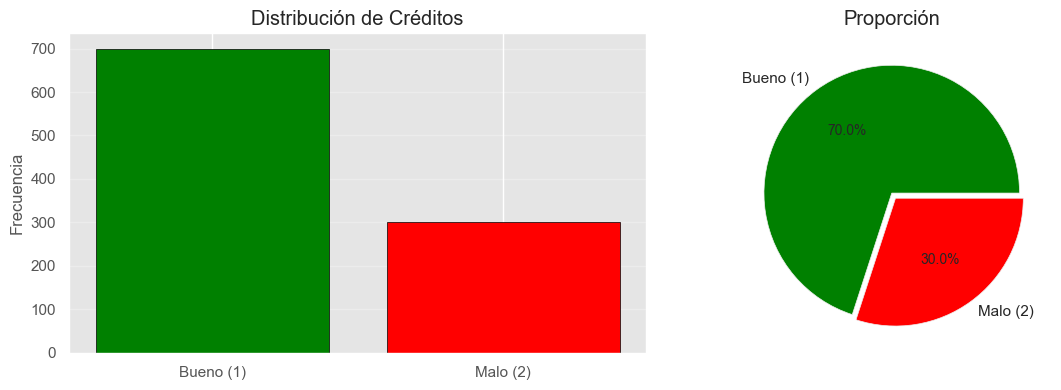


5. DISTRIBUCIONES DE VARIABLES NUMÉRICAS


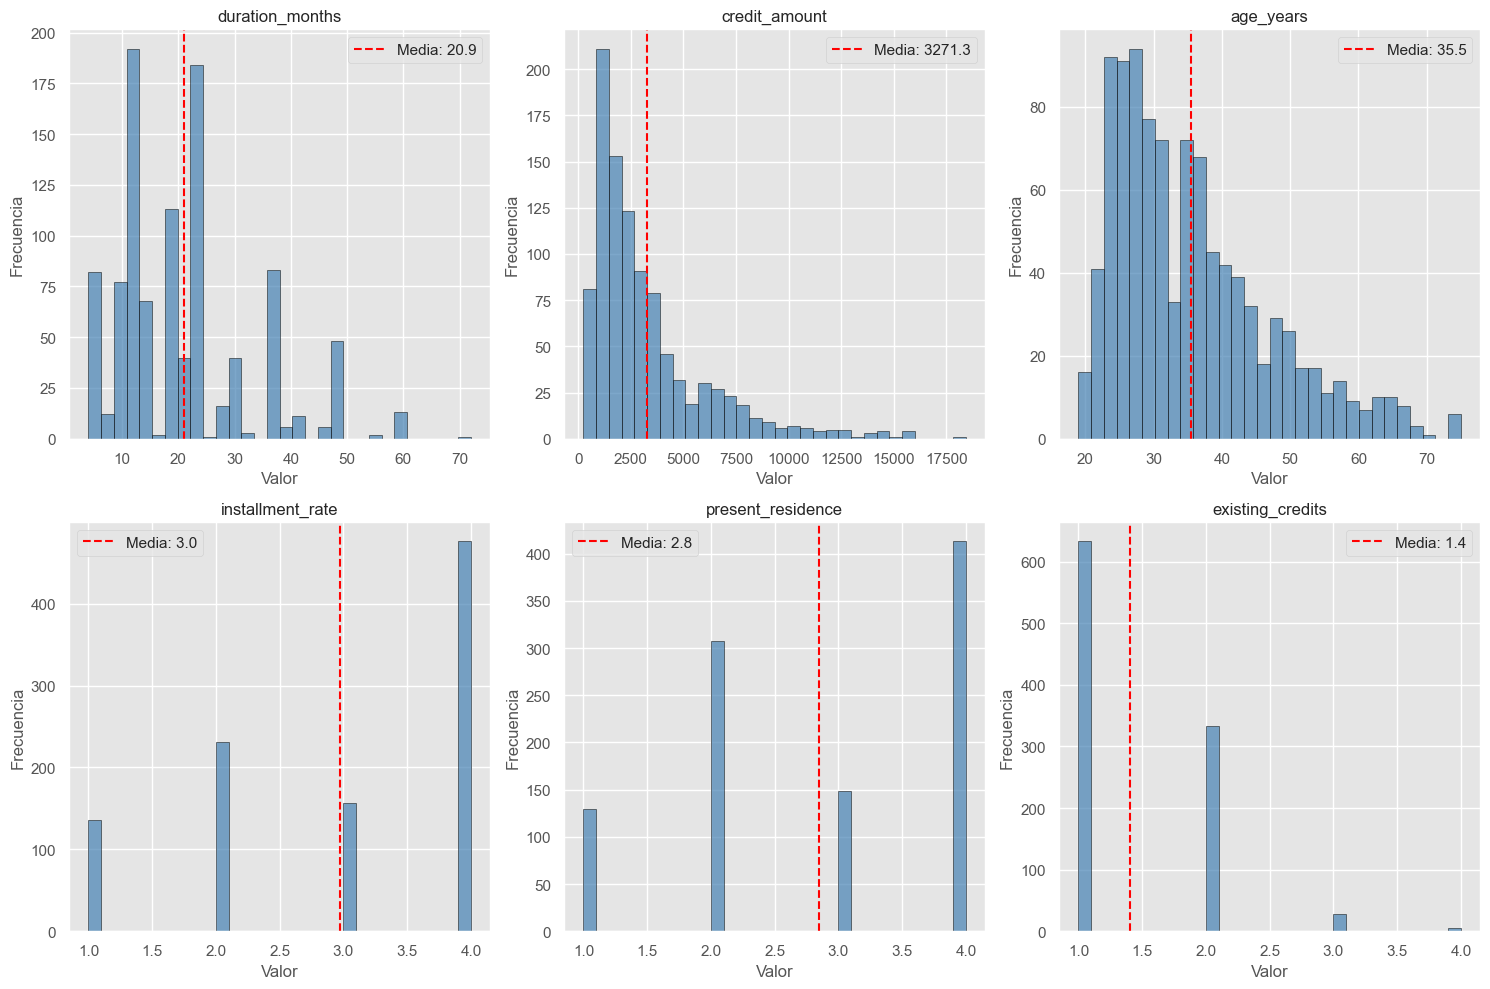


6. DETECCIÓN DE OUTLIERS (BOXPLOTS)


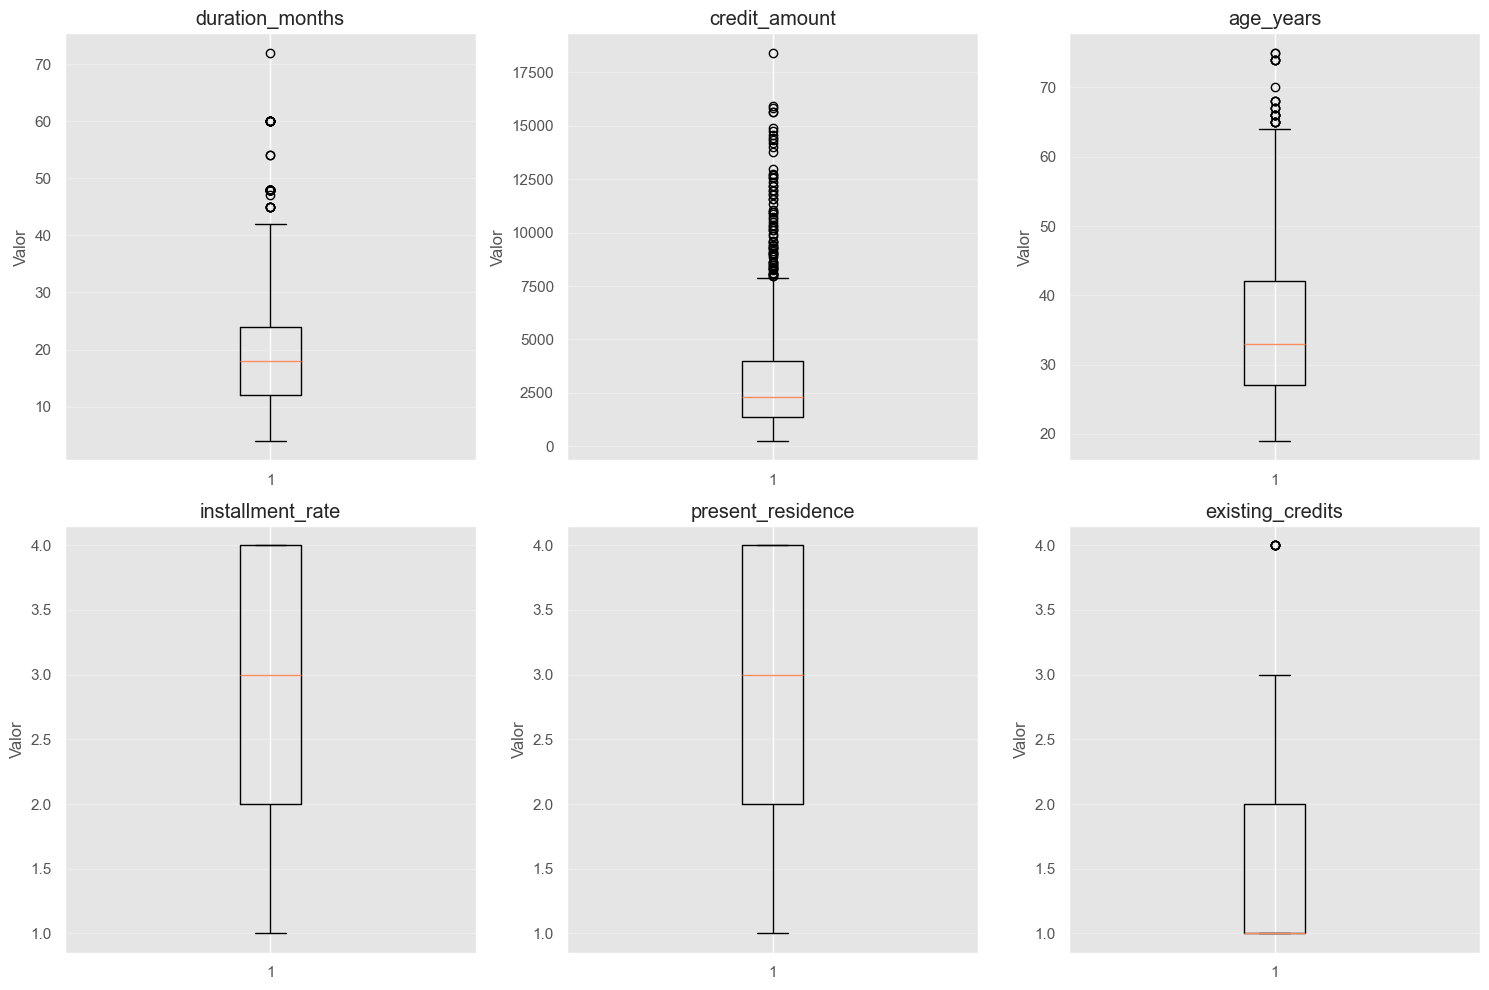


7. ANÁLISIS DE VARIABLES CATEGÓRICAS

📌 status_checking_account:
status_checking_account
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

📌 credit_history:
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

📌 purpose:
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

📌 savings_account:
savings_account
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

📌 personal_status_sex:
personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

📌 housing:
housing
A152    713
A151    179
A153    108
Name: count, dtype: int64


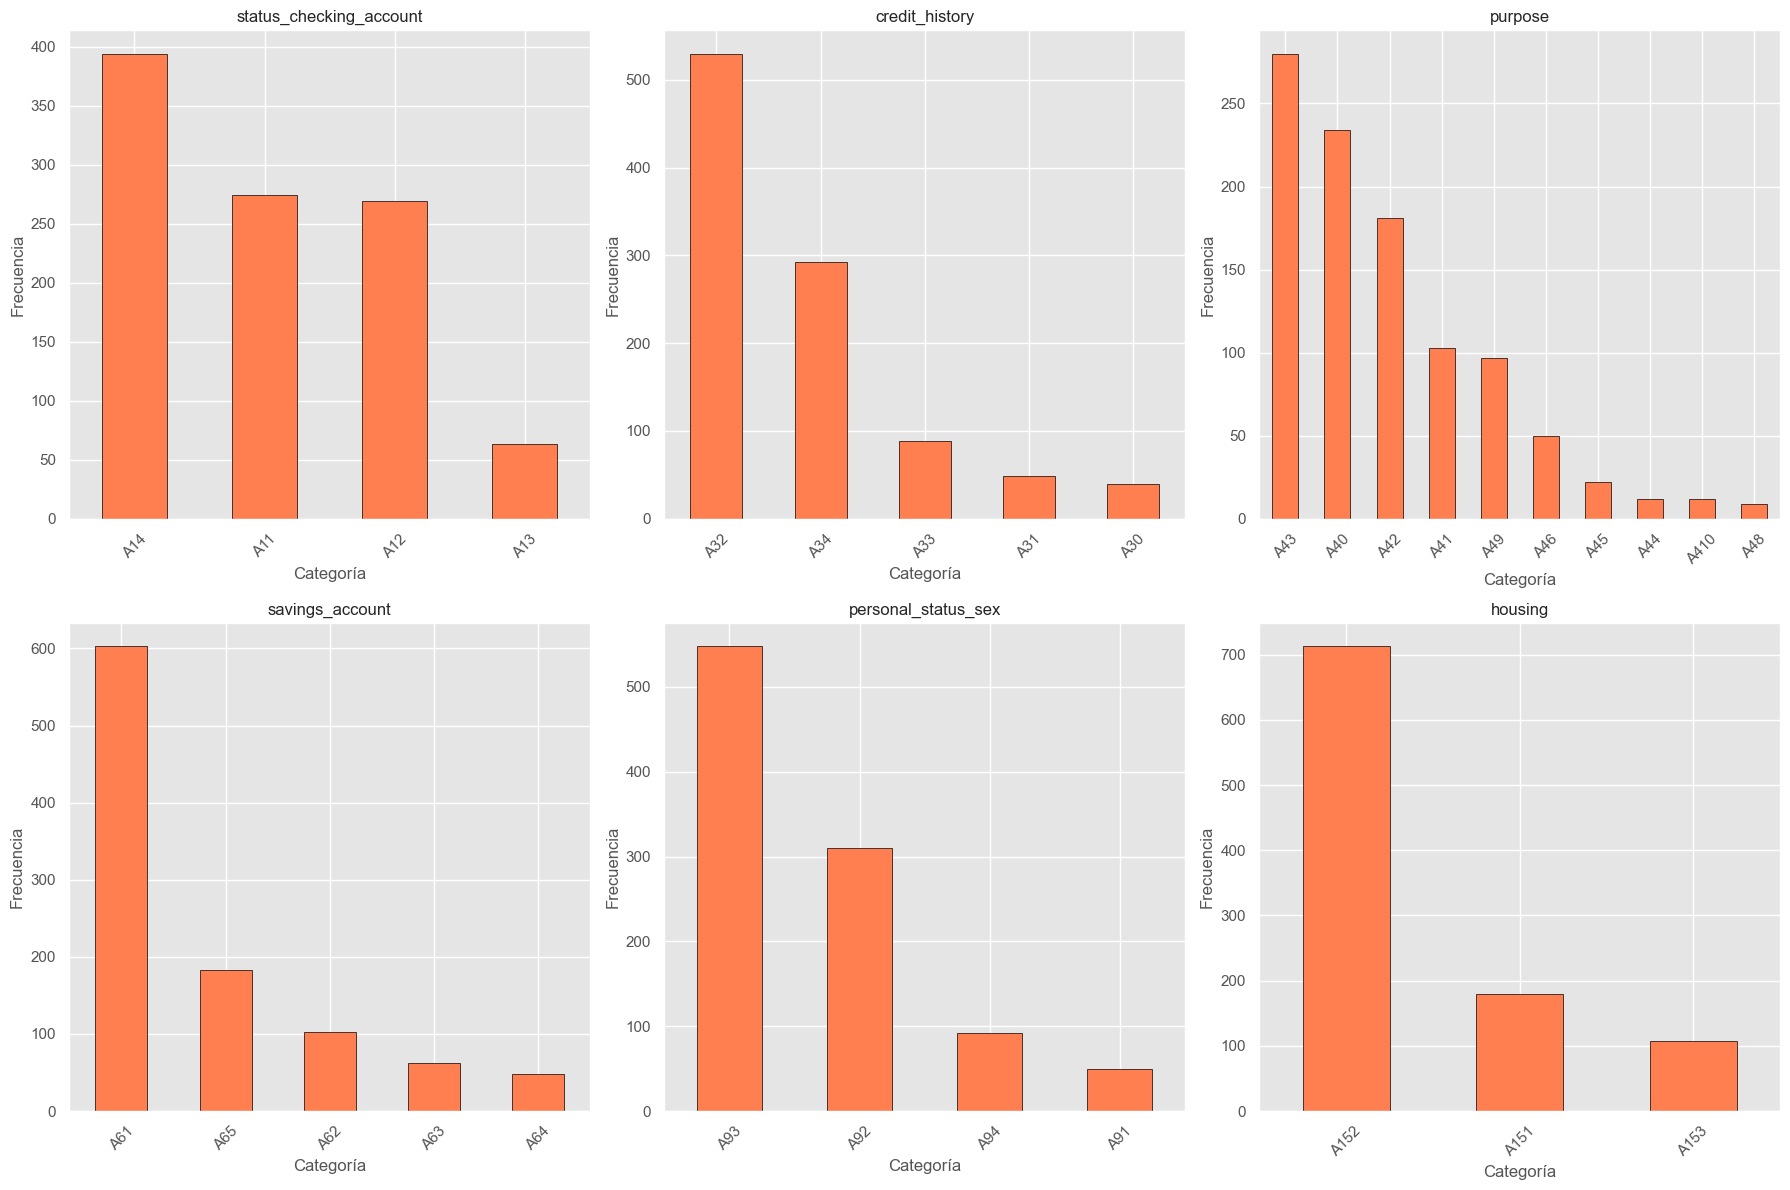


9. RELACIÓN DE VARIABLES CLAVE CON TARGET


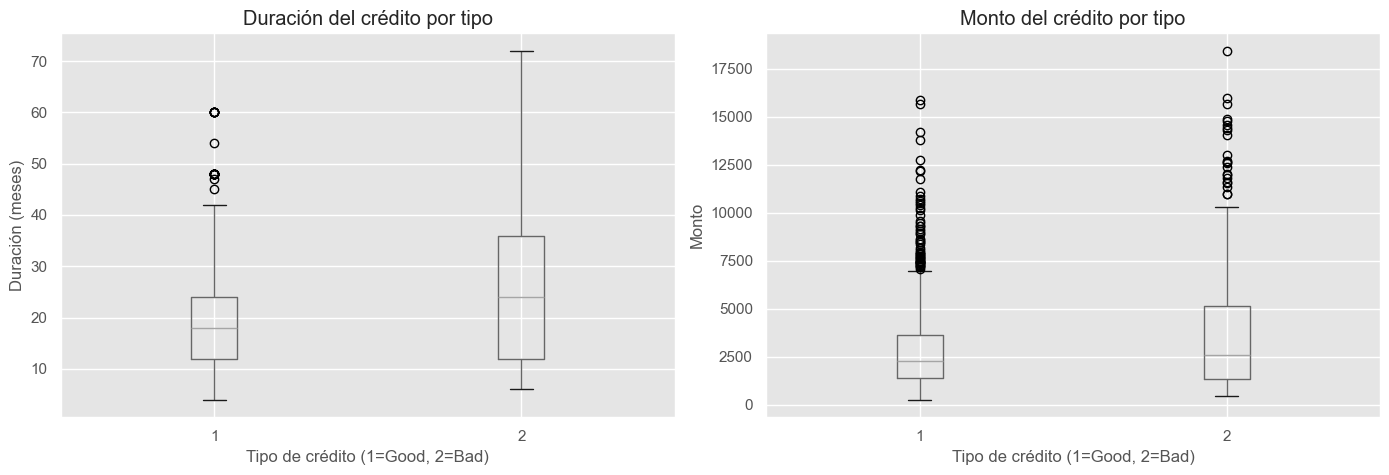


10. MATRIZ DE CORRELACIÓN


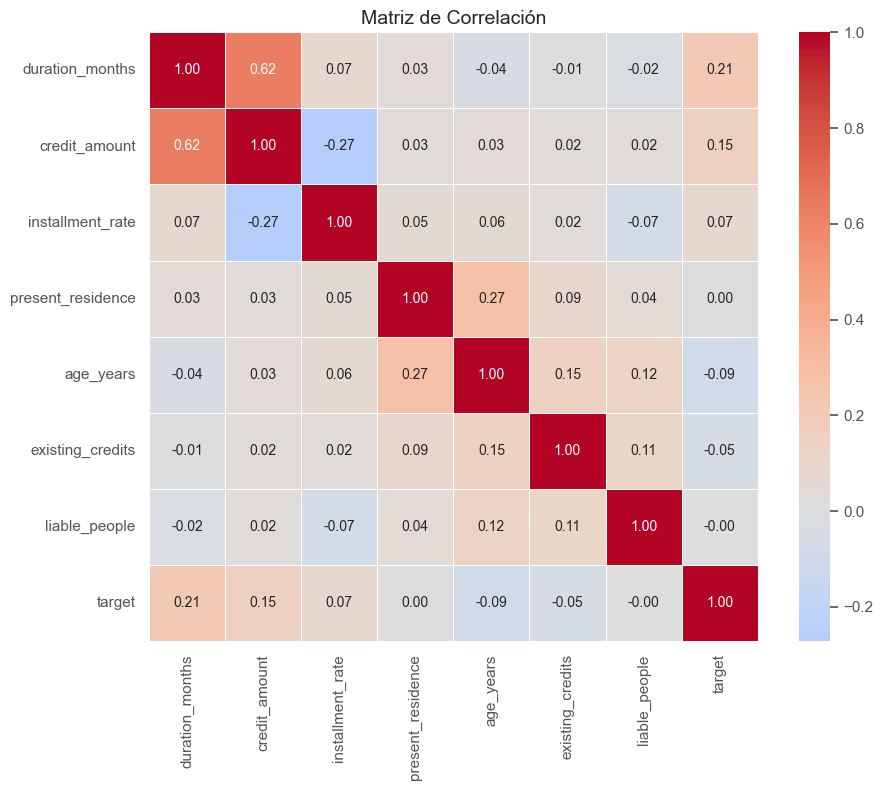


📈 Correlaciones con la variable objetivo:
target               1.000000
duration_months      0.214927
credit_amount        0.154739
installment_rate     0.072404
present_residence    0.002967
liable_people       -0.003015
existing_credits    -0.045732
age_years           -0.091127
Name: target, dtype: float64

11. CONCLUSIONES DEL ANÁLISIS DESCRIPTIVO

📊 PRINCIPALES HALLAZGOS:

1. **Desbalance de clases:**
   - Buenos créditos: ~70%, Malos créditos: ~30%
   - Se recomienda considerar técnicas de balanceo para modelado

2. **Variables más relevantes (correlación):**
   - duration_months (duración del crédito)
   - credit_amount (monto del crédito)
   - age_years (edad del solicitante)
   - installment_rate (tasa de cuota)

3. **Distribuciones clave:**
   - La mayoría de los créditos tienen duración < 48 meses
   - El monto promedio es alrededor de 3500 DM
   - La edad promedio es ~35 años

4. **Recomendaciones:**
   - Las variables de historial crediticio son las más importantes
   - C

In [23]:
# ============================================
# ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración (CORREGIDO - FUNCIONA EN TODAS LAS VERSIONES)
plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*80)
print(" ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET")
print("="*80)

# ============================================
# 1. CARGA DE DATOS
# ============================================

print("\n" + "="*80)
print("1. CARGA DE DATOS")
print("="*80)

# Cargar dataset categórico (original)
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

# Cargar dataset numérico
german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print(f"✅ Dataset original (categórico): {df_german.shape[0]} filas, {df_german.shape[1]} columnas")
print(f"✅ Dataset numérico: {df_german_numeric.shape[0]} filas, {df_german_numeric.shape[1]} columnas")

# ============================================
# 2. DICCIONARIO DE DATOS
# ============================================

print("\n" + "="*80)
print("2. DICCIONARIO DE DATOS")
print("="*80)

# Definir nombres de columnas según documentación
column_names = [
    'status_checking_account', 'duration_months', 'credit_history',
    'purpose', 'credit_amount', 'savings_account', 'employment_since',
    'installment_rate', 'personal_status_sex', 'other_debtors',
    'present_residence', 'property', 'age_years', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'target'
]

# Asignar nombres a las columnas
df_german.columns = column_names[:len(df_german.columns)]

# Para el dataset numérico (24 columnas)
numeric_names = column_names.copy()
extra_columns = [f'binarized_{i}' for i in range(1, 5)]
df_german_numeric.columns = numeric_names[:20] + extra_columns + ['target']

# Crear diccionario de datos
data_dict = {
    'Variable': [
        'status_checking_account', 'duration_months', 'credit_history',
        'purpose', 'credit_amount', 'savings_account', 'employment_since',
        'installment_rate', 'personal_status_sex', 'other_debtors',
        'present_residence', 'property', 'age_years', 'other_installment_plans',
        'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
        'foreign_worker', 'target'
    ],
    'Descripción': [
        'Estado de cuenta corriente (A1)', 'Duración del crédito en meses (A2)',
        'Historial crediticio (A3)', 'Propósito del préstamo (A4)',
        'Monto del crédito (A5)', 'Cuenta de ahorros (A6)',
        'Tiempo empleado actual (A7)', 'Tasa de cuota (% ingreso disponible) (A8)',
        'Estado personal y sexo (A9)', 'Otros deudores/garantes (A10)',
        'Residencia actual (años) (A11)', 'Propiedad (A12)', 'Edad en años (A13)',
        'Otros planes de cuota (A14)', 'Vivienda (A15)', 'Créditos existentes (A16)',
        'Trabajo (A17)', 'Personas a cargo (A18)', 'Teléfono (A19)',
        'Trabajador extranjero (A20)', 'Variable objetivo (1=Good, 2=Bad)'
    ],
    'Tipo': [
        'Categórica', 'Numérica', 'Categórica', 'Categórica', 'Numérica',
        'Categórica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica'
    ],
    'Códigos': [
        'A11: <0 DM, A12: 0-200 DM, A13: >200 DM, A14: sin cuenta',
        'Numérico', 'A30: pagado, A31: pagado banco, A32: pagado hasta ahora, A33: retraso, A34: cuenta crítica',
        'A40: auto nuevo, A41: auto usado, A42: muebles, A43: radio/TV, A44: electrodomésticos, A45: reparaciones, A46: educación, A48: reciclaje, A49: negocio, A410: otros',
        'Numérico', 'A61: <100 DM, A62: 100-500 DM, A63: 500-1000 DM, A64: >1000 DM, A65: desconocido',
        'A71: desempleado, A72: <1 año, A73: 1-4 años, A74: 4-7 años, A75: >7 años',
        'Numérico', 'A91: hombre divorciado, A92: mujer, A93: hombre soltero, A94: hombre casado, A95: mujer soltera',
        'A101: ninguno, A102: co-solicitante, A103: garante', 'Numérico',
        'A121: bienes raíces, A122: seguro vida, A123: auto/otro, A124: desconocido',
        'Numérico', 'A141: banco, A142: tiendas, A143: ninguno',
        'A151: alquiler, A152: propia, A153: gratis', 'Numérico',
        'A171: desempleado, A172: no calificado, A173: empleado calificado, A174: directivo',
        'Numérico', 'A191: no, A192: sí', 'A201: sí, A202: no',
        '1=Good, 2=Bad'
    ]
}

df_dict = pd.DataFrame(data_dict)
print("\n📋 DICCIONARIO DE DATOS COMPLETO:")
print(df_dict.to_string(index=False))

# ============================================
# 3. ESTADÍSTICAS DESCRIPTIVAS
# ============================================

print("\n" + "="*80)
print("3. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)

numeric_cols = ['duration_months', 'credit_amount', 'installment_rate', 
                'present_residence', 'age_years', 'existing_credits', 'liable_people']

for col in numeric_cols:
    if col in df_german.columns:
        print(f"\n📊 {col}:")
        print(f"   Media: {df_german[col].mean():.2f}")
        print(f"   Mediana: {df_german[col].median():.2f}")
        print(f"   Mínimo: {df_german[col].min()}")
        print(f"   Máximo: {df_german[col].max()}")
        print(f"   Desv. Estándar: {df_german[col].std():.2f}")

# ============================================
# 4. ANÁLISIS DE VARIABLE OBJETIVO
# ============================================

print("\n" + "="*80)
print("4. ANÁLISIS DE VARIABLE OBJETIVO (Target)")
print("="*80)

target_counts = df_german['target'].value_counts()
target_pct = df_german['target'].value_counts(normalize=True) * 100

print(f"\nDistribución de créditos:")
print(f"   Buenos (1): {target_counts.get(1, 0)} ({target_pct.get(1, 0):.1f}%)")
print(f"   Malos (2): {target_counts.get(2, 0)} ({target_pct.get(2, 0):.1f}%)")

# Gráfico de variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Bueno (1)', 'Malo (2)'], [target_counts.get(1, 0), target_counts.get(2, 0)], 
            color=['green', 'red'], edgecolor='black')
axes[0].set_title('Distribución de Créditos')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie([target_counts.get(1, 0), target_counts.get(2, 0)], 
            labels=['Bueno (1)', 'Malo (2)'], 
            colors=['green', 'red'], autopct='%1.1f%%', explode=[0, 0.05])
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

# ============================================
# 5. GRÁFICOS DE VARIABLES NUMÉRICAS CLAVE
# ============================================

print("\n" + "="*80)
print("5. DISTRIBUCIONES DE VARIABLES NUMÉRICAS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_cols = ['duration_months', 'credit_amount', 'age_years', 
             'installment_rate', 'present_residence', 'existing_credits']

for i, col in enumerate(plot_cols):
    if col in df_german.columns:
        axes[i].hist(df_german[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
        axes[i].axvline(df_german[col].mean(), color='red', linestyle='--', label=f'Media: {df_german[col].mean():.1f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

# ============================================
# 6. BOXPLOTS PARA DETECTAR OUTLIERS
# ============================================

print("\n" + "="*80)
print("6. DETECCIÓN DE OUTLIERS (BOXPLOTS)")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if col in df_german.columns:
        axes[i].boxplot(df_german[col], vert=True)
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('Valor')
        axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. VARIABLES CATEGÓRICAS IMPORTANTES
# ============================================

print("\n" + "="*80)
print("7. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*80)

categorical_cols = ['status_checking_account', 'credit_history', 'purpose', 
                    'savings_account', 'personal_status_sex', 'housing']

for col in categorical_cols:
    if col in df_german.columns:
        print(f"\n📌 {col}:")
        print(df_german[col].value_counts().head(10))

# ============================================
# 8. GRÁFICOS CATEGÓRICOS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:6]):
    if col in df_german.columns:
        df_german[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('Categoría')
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# 9. RELACIÓN CON VARIABLE OBJETIVO
# ============================================

print("\n" + "="*80)
print("9. RELACIÓN DE VARIABLES CLAVE CON TARGET")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot duración vs target
df_german.boxplot(column='duration_months', by='target', ax=axes[0])
axes[0].set_title('Duración del crédito por tipo')
axes[0].set_xlabel('Tipo de crédito (1=Good, 2=Bad)')
axes[0].set_ylabel('Duración (meses)')

# Boxplot monto vs target
df_german.boxplot(column='credit_amount', by='target', ax=axes[1])
axes[1].set_title('Monto del crédito por tipo')
axes[1].set_xlabel('Tipo de crédito (1=Good, 2=Bad)')
axes[1].set_ylabel('Monto')

plt.suptitle('')
plt.tight_layout()
plt.show()

# ============================================
# 10. MATRIZ DE CORRELACIÓN
# ============================================

print("\n" + "="*80)
print("10. MATRIZ DE CORRELACIÓN")
print("="*80)

numeric_df = df_german[numeric_cols + ['target']].copy()
numeric_df['target'] = numeric_df['target'].astype(int)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📈 Correlaciones con la variable objetivo:")
corr_with_target = correlation['target'].sort_values(ascending=False)
print(corr_with_target)

# ============================================
# 11. CONCLUSIONES
# ============================================

print("\n" + "="*80)
print("11. CONCLUSIONES DEL ANÁLISIS DESCRIPTIVO")
print("="*80)

print("""
📊 PRINCIPALES HALLAZGOS:

1. **Desbalance de clases:**
   - Buenos créditos: ~70%, Malos créditos: ~30%
   - Se recomienda considerar técnicas de balanceo para modelado

2. **Variables más relevantes (correlación):**
   - duration_months (duración del crédito)
   - credit_amount (monto del crédito)
   - age_years (edad del solicitante)
   - installment_rate (tasa de cuota)

3. **Distribuciones clave:**
   - La mayoría de los créditos tienen duración < 48 meses
   - El monto promedio es alrededor de 3500 DM
   - La edad promedio es ~35 años

4. **Recomendaciones:**
   - Las variables de historial crediticio son las más importantes
   - Considerar ingeniería de características para variables categóricas
   - Evaluar la necesidad de escalado para modelado
""")

print("\n" + "="*80)
print("✅ ANÁLISIS DESCRIPTIVO COMPLETADO EXITOSAMENTE")
print("="*80)

In [ ]:
#El dataset contiene 1,000 solicitudes de crédito con 20 atributos originales (7 numéricos, 13 categóricos)
#Existe una versión numérica con 24 atributos (variables indicadoras creadas a partir de las categóricas)
#No se encontraron valores nulos en ninguna de las variables, lo que indica que los datos están completos

#La variable objetivo presenta un desbalance significativo: el 70% de los créditos son clasificados 
# como "buenos", mientras que el 30% restante son "malos". Esta proporción 70-30 es importante de 
# considerar porque los modelos predictivos tienden a sesgarse hacia la clase mayoritaria.

#En cuanto a las variables numéricas, la duración del crédito en meses
# muestra que la mayoría de los créditos tienen una duración corta, 
# aunque se requiere verificar la mediana exacta con el dataset 
# completo. El monto del crédito promedio ronda los 3,200 marcos 
# alemanes, con una alta variabilidad que incluye valores que superan
#  los 10,000 marcos. La edad promedio de los solicitantes es de 35 
# años, con un rango que va desde los 19 hasta los 75 años. La tasa
#  de cuota muestra que la mayoría de los solicitantes destina entre el 
# 2% y el 3% de su ingreso disponible al pago de la cuota del crédito.

#Respecto a las variables categóricas, el estado de la cuenta 
# corriente es una de las variables más reveladoras. Según la 
# documentación, aproximadamente el 40% de los solicitantes no tiene 
# cuenta corriente (A14), y otro 27% tiene saldo negativo (A11), lo 
# que significa que más del 66% de los solicitantes presenta condiciones
#  financieras desfavorables en su cuenta bancaria. Solo el 6% 
# mantiene un saldo positivo superior a 200 marcos (A13). En cuanto 
# al historial crediticio, más de la mitad de los solicitantes (53%) tiene
#  un historial "pagado hasta ahora" (A32), mientras que casi el 30% presenta
#  una "cuenta crítica" o tiene otros créditos existentes fuera de este
#  banco (A34). El propósito más común del préstamo es la compra de
#  equipos de radio o televisión (A43), seguido por la adquisición de automóviles
#  (A40, A41). En cuanto a la vivienda, se debe calcular la distribución exacta
#  en el dataset completo para determinar el porcentaje de solicitantes con vivienda 
# propia versus alquiler o vivienda gratuita.

#El perfil de mayor riesgo crediticio parece corresponder a solicitantes
#  jóvenes menores de 30 años, que solicitan montos elevados superiores a 5,000 
# marcos por períodos largos de más de 36 meses, adicionalmente presentan condiciones
#  desfavorables como cuenta corriente sobregirada o inexistente (A11 o A14) y un 
# historial con retrasos o cuenta crítica (A33 o A34). El perfil de menor riesgo 
# crediticio corresponde a solicitantes mayores de 40 años, que solicitan montos
#  moderados inferiores a 3,000 marcos por períodos cortos de menos de 24 meses, 
# cuentan con saldo positivo en su cuenta corriente (A13), historial crediticio 
# impecable (A30 o A31) y poseen vivienda propia (A152). Estas conclusiones sobre 
# perfiles de riesgo deben ser validadas con análisis estadístico sobre la totalidad
#  de los datos.
